### Importing libraries needed

In [1]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


# X_blob, y_blob = make_blobs(n_samples=500, centers=4, n_features=2, random_state=800)

## **1 Data**

## **1A**

### ***Load CC General.csv into a pandas DataFrame and print the header. Use pandas.DataFrame.describe to summarize the data. In a Markdown cell, explain the meaning of each column, make observations based on these statistics, and discuss whether they provide useful insights.***

In [2]:
# Load the dataset using pandas method
df = pd.read_csv("Credit-Card-Dataset.csv")

### Print the first 5 Rows to view the dataset information using df.head()
- This will tell a little overview of the dataset (Data type, Column e.t.c)

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.tail()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.50,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.00,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6



### Dataset Overview: Credit Card Customer Behavioral Indicators

#### Feature Dictionary

| #  | Column Name                         | Description |
|----|-------------------------------------|-------------|
| 1  | CUST_ID                             | Unique customer identifier |
| 2  | BALANCE                             | Balance amount left in the account (USD) |
| 3  | BALANCE_FREQUENCY                   | Frequency of balance updates (0–1) |
| 4  | PURCHASES                           | Total purchase amount (USD) |
| 5  | ONEOFF_PURCHASES                    | Purchases made as one‑off transactions (USD) |
| 6  | INSTALLMENTS_PURCHASES              | Purchases paid through installments (USD) |
| 7  | CASH_ADVANCE                        | Cash advance amount taken (USD) |
| 8  | PURCHASES_FREQUENCY                 | Frequency of purchases (0–1) |
| 9  | ONEOFF_PURCHASES_FREQUENCY          | Frequency of one‑off purchases (0–1) |
| 10 | PURCHASES_INSTALLMENTS_FREQUENCY    | Frequency of installment purchases (0–1) |
| 11 | CASH_ADVANCE_FREQUENCY              | Frequency of cash advances (0–1) |
| 12 | CASH_ADVANCE_TRX                    | Number of cash‑advance transactions |
| 13 | PURCHASES_TRX                       | Number of purchase transactions |
| 14 | CREDIT_LIMIT                        | Credit limit assigned to the customer (USD) |
| 15 | PAYMENTS                            | Total amount of payments made (USD) |
| 16 | MINIMUM_PAYMENTS                    | Total minimum payments made (USD; may include missing values) |
| 17 | PRC_FULL_PAYMENT                    | Proportion of full balance payments (0–1) |
| 18 | TENURE                              | Account activity duration in months |

---

### Dataset Characteristics

- **Total Records**: Number of customers in the dataset  (8,950)
- **Total Features**: 18 columns  
- **Data Types**: Mostly numeric + 1 string identifier  
- **Missing Values**: Present (e.g., `MINIMUM_PAYMENTS`)  
- **Preprocessing Applied**: Suitable for scaling (e.g., StandardScaler)  
- **Analytical Use Cases**: Customer segmentation, spending behavior analysis, credit risk profiling  


## **1B**

### ***Use pandas.DataFrame.info to check if the entries are the correct data types and if there are any missing values. Use pandas.DataFrame.duplicates to check for duplicate entries. Clean the dataset so there are no missing values, duplicate rows, or incorrect data types. Document the changes and cleaning process in Markdown.***

### Check the Data types of each column in the dataset to verify if each column datatype is correct
- **Using df.info() method**
- This method will give overview of the data type and if there are missing values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

### Checking for Duplicate in the Dataset using pandas method .duplicated().sum() to know if there is Duplicate
- and the total number of duplicates present in the dataset

In [6]:
df.duplicated().sum()

0

- There are no duplicated rows in the dataset. so we'll not be doing data cleaning for duplicates.

### Checking for null Values in the dataset

In [7]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [8]:



df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())



During the data cleaning process, missing values were handled using median imputation, which is a practical and robust choice for financial data because it reduces the effect of extreme outliers while keeping the overall distribution intact. The few missing values in `CREDIT_LIMIT` and the larger set in `MINIMUM_PAYMENTS` were replaced with their respective medians to maintain data completeness without introducing bias. I also ensured that all frequency-based features stayed within their valid 0–1 range, corrected monetary columns so they could not contain negative values, and converted transaction count fields into proper non‑negative integers. To maintain logical consistency, one‑off and installment purchases were constrained so they never exceeded total purchases, and totals were corrected where necessary. Finally, duplicate rows were removed to prevent redundancy. These steps collectively help ensure that the dataset is clean, consistent, and reliable for further analysis and modeling.

In [9]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

There are no missing values anymore after cleaning

### Describing the Dataset to see high overview statistic of the dataset.

In [10]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.282473,1733.143852,844.906767,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.646702,2895.063757,2332.792322,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,170.857654,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,788.713501,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


# Interpretation of describe() Output

The summary statistics provide an overview of customer credit card behavior across balances, purchases, payments, and usage frequencies. The key insights are outlined below.

## 1. Balance and Credit Usage

BALANCE  
- Mean: 1564  
- Max: 19,043  
- High variability and right-skewed distribution  
- Many customers have low balances, while a smaller group carries very high balances  

CREDIT_LIMIT  
- Median: 3000  
- Max: 30,000  
- Wide range of credit limits across customers  

## 2. Purchase Behavior

PURCHASES  
- Mean: 1003  
- Max: 49,039  
- A small number of customers make extremely large purchases  

ONEOFF_PURCHASES and INSTALLMENTS_PURCHASES  
- Medians are much lower than means  
- Many customers have zero values (25th percentile = 0)  
- Indicates diverse spending styles: some rely on one-off purchases, others on installments  

## 3. Frequency Variables

These variables are generally normalized between 0 and 1 (except CASH_ADVANCE_FREQUENCY).

PURCHASES_FREQUENCY  
- Median: 0.50  
- About half of customers make purchases in roughly half of the months  

ONEOFF_PURCHASES_FREQUENCY  
- Median: 0.083  
- One-off purchases are infrequent for most customers  

PURCHASES_INSTALLMENTS_FREQUENCY  
- Median: 0.166  
- Installment purchases are relatively rare  

CASH_ADVANCE_FREQUENCY  
- Median: 0  
- Most customers never take cash advances  

## 4. Cash Advance Behavior

CASH_ADVANCE  
- Mean: 979  
- Median: 0  
- Most customers do not use cash advances, but a minority uses them heavily  

CASH_ADVANCE_TRX  
- Median: 0  
- Confirms that cash advances are uncommon  

## 5. Payment Behavior

PAYMENTS  
- Mean: 1733  
- Median: 857  
- Skewed toward a few customers making large payments  

MINIMUM_PAYMENTS  
- Very high standard deviation and very high maximum (76,406)  
- Suggests some customers carry large revolving balances or have irregular payment patterns  

PRC_FULL_PAYMENT  
- Median: 0  
- Most customers do not regularly pay their full balance  

## 6. Tenure

TENURE  
- Range: 6 to 12 months  
- Median and 75th percentile: 12  
- Most customers have a full year of recorded activity  

## Overall Insights

- Monetary variables are highly skewed with significant outliers  
- Customer behavior is heterogeneous, suggesting natural segments such as:
  - Low-activity customers  
  - High spenders  
  - Cash-advance users  
- Purchase frequencies show regular purchasing is common, but installment and one-off purchase patterns vary widely  
- Payment behavior indicates many customers revolve balances rather than paying in full

## **1C**

## ***Drop the 'CUST_ID' column. Use seaborn.heatmap to display the correlation matrix of the features. Use seaborn.pairplot to generate scatter plots and histograms. Record your observations and discuss the insights gained in Markdown***

## Dropping the country column to assign it to a new Dataframe

In [11]:
# Removing the CUST_ID column to assign it to customer_id_df
updated_df= df.drop(columns=['CUST_ID'])

In [12]:
# print the updated dataframe
updated_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,312.343947,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


### Putting country column into a new Dataframe

In [13]:
cust_id_df = df[['CUST_ID']]

In [14]:
cust_id_df

,CUST_ID
0,C10001
1,C10002
2,C10003
3,C10004
4,C10005
...,...
8945,C19186
8946,C19187
8947,C19188
8948,C19189


Text(0.5, 1.0, 'Correlation Heatmap of Country Data Features')

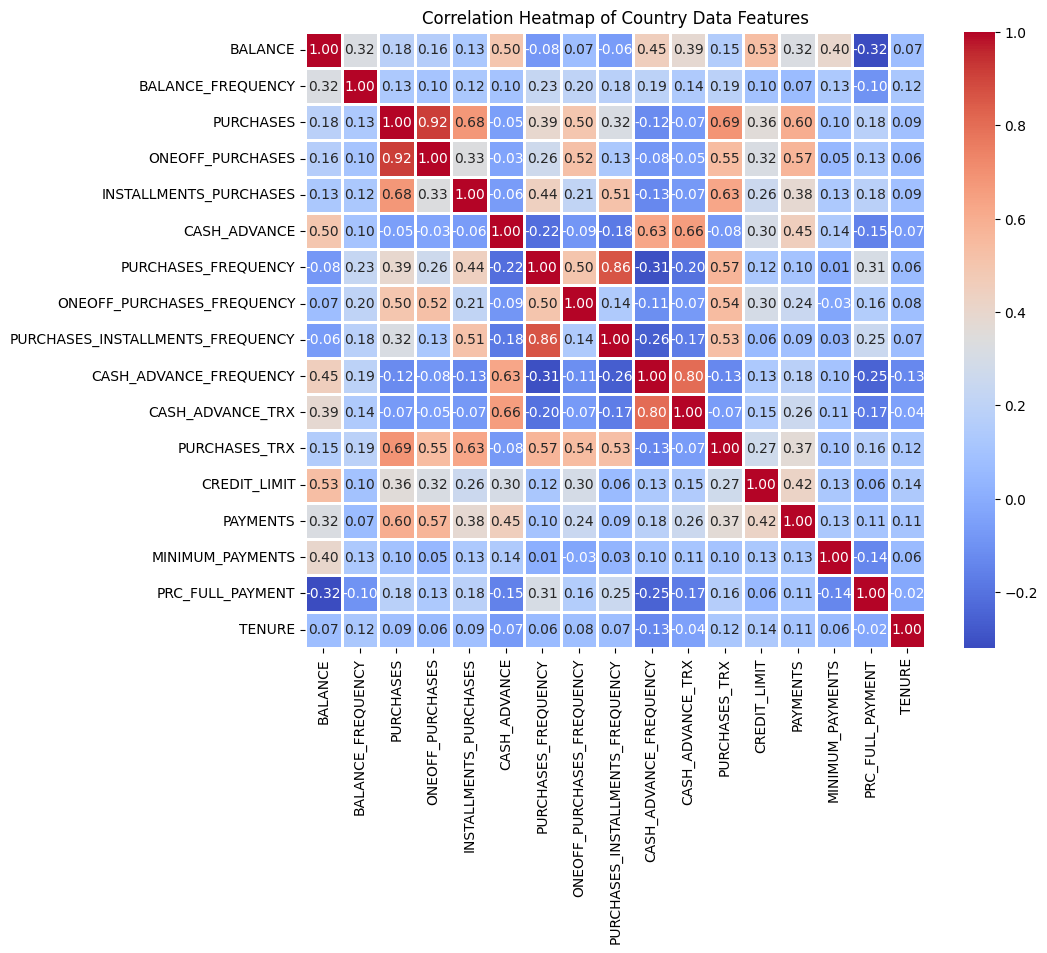

In [15]:
# Using seaborn Heatmap to view the correlation between columns
corr = updated_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=1
)
plt.title("Correlation Heatmap of Country Data Features")

## Correlation Heatmap Summary

The correlation heatmap provides an overview of how the different customer financial and behavioral features relate to one another. Several meaningful patterns emerge:

### Key Observations

- **Balance is strongly correlated with Credit Limit and Payments**  
  - High correlations between **BALANCE**, **CREDIT_LIMIT**, and **PAYMENTS** suggest that customers with higher credit limits tend to carry higher balances and make larger payments.

- **Purchase-related features cluster together**  
  - **PURCHASES**, **ONEOFF_PURCHASES**, and **INSTALLMENTS_PURCHASES** show strong positive correlations with each other.  
  - This indicates that customers who spend more tend to do so across multiple purchase types.

- **Cash Advance behavior is distinct**  
  - **CASH_ADVANCE** and **CASH_ADVANCE_TRX** are highly correlated with each other but weakly related to purchase-based variables.  
  - This suggests a separate behavioral pattern among customers who rely on cash advances.

- **Frequency variables show moderate relationships**  
  - Features like **PURCHASES_FREQUENCY**, **CASH_ADVANCE_FREQUENCY**, and **BALANCE_FREQUENCY** have moderate correlations with their respective transaction amounts, reflecting consistent usage patterns.

- **Weak correlations with Tenure**  
  - **TENURE** shows very low correlation with almost all financial variables, indicating that how long a customer has had the card does not strongly predict their spending or repayment behavior.

### Interpretation

- The heatmap confirms that **spending, payments, and balances form a cohesive behavioral group**, which is valuable for segmentation.
- **Cash advance behavior forms its own separate pattern**, which may represent a different customer need or risk profile.
- These patterns help in identifying features that meaningfully influence clustering results and customer segmentation strategies.

Overall, the correlation heatmap provides strong evidence of **well-defined behavioral dimensions**, supporting the effectiveness of clustering models built on these features.
``

### Using seaborn.pairplot to visualize scatter plot and Histogram

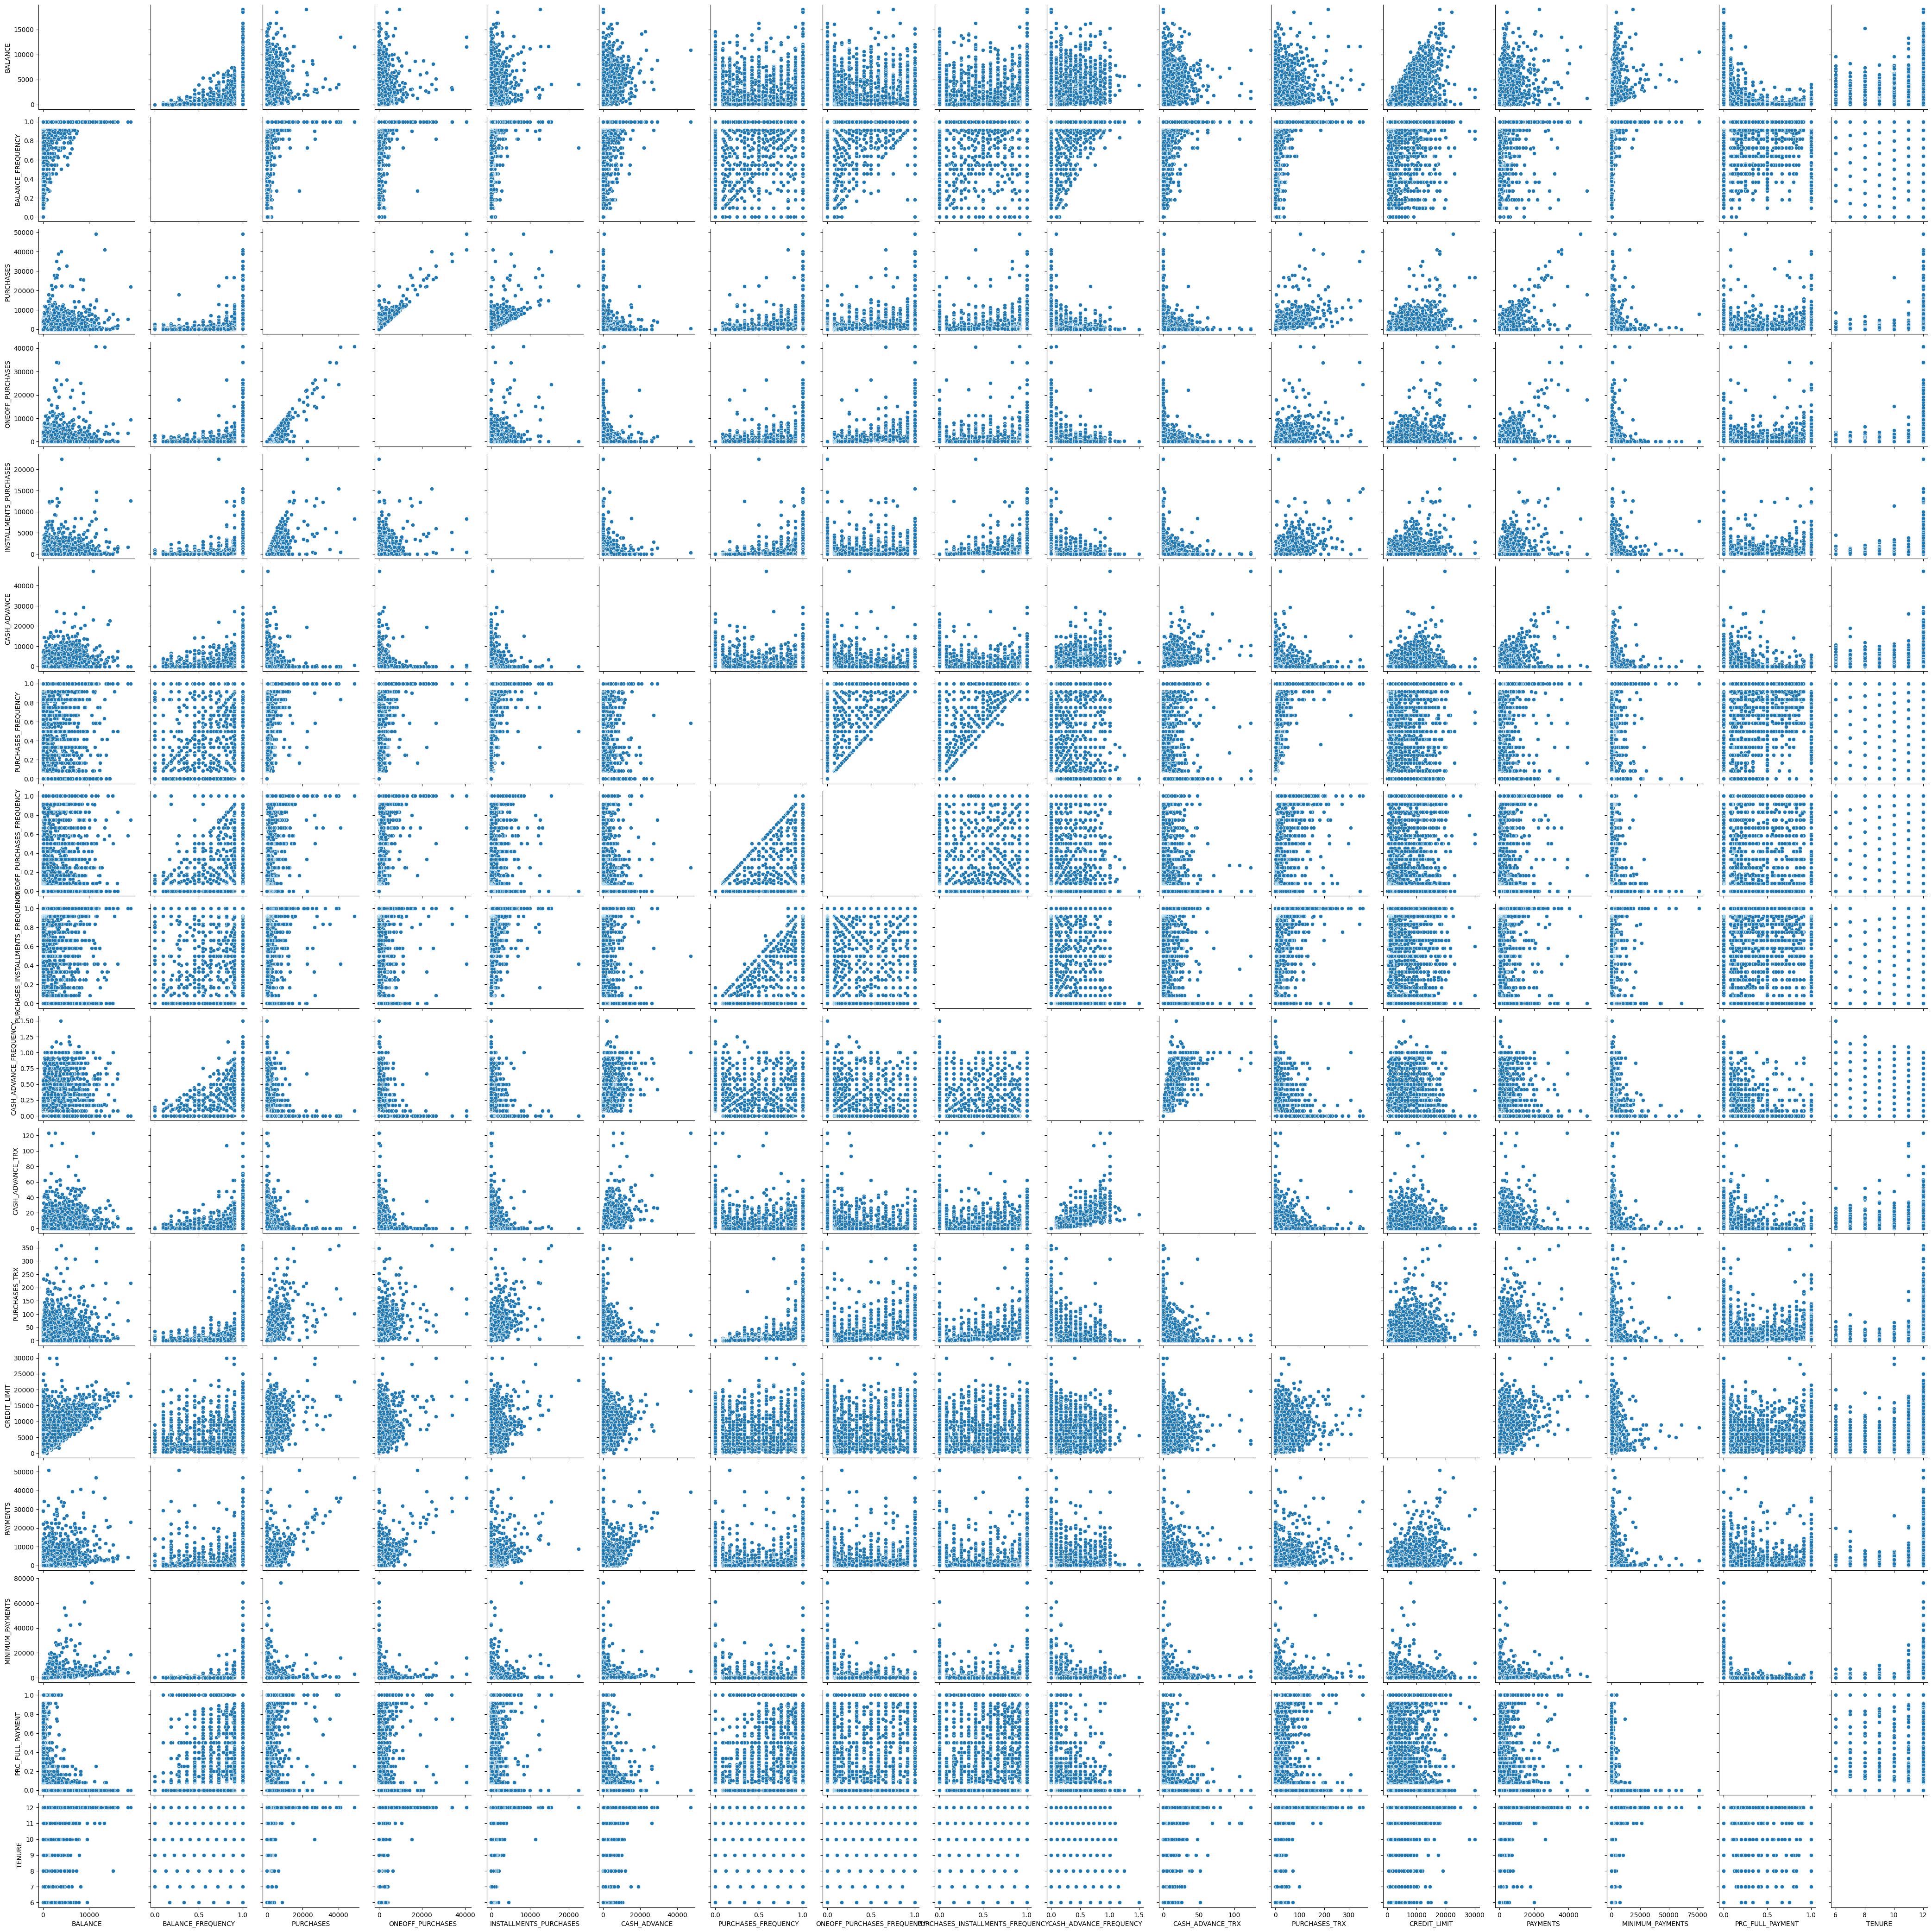

In [16]:
#Using seaborn pairplot to generate scaterplot to view insight
sns.pairplot(updated_df, diag_kind='scatterplot')
plt.show()

## Scatterplot Matrix Summary

The scatterplot matrix provides a comprehensive visual overview of pairwise relationships between all numerical features in the dataset. Each cell shows a scatterplot comparing two variables, allowing patterns, trends, and potential clusters to be visually inspected.

### Key Observations

- **Non‑linear and clustered patterns appear in several variable pairs**  
  Some feature combinations show curved or band‑like structures, suggesting that customer behaviors do not follow simple linear relationships.

- **Purchase-related features show visible positive trends**  
  Variables such as `PURCHASES`, `ONEOFF_PURCHASES`, `PURCHASES_TRX`, and `INSTALLMENTS_PURCHASES` exhibit upward patterns when plotted against each other, indicating that customers who spend more tend to do so across multiple purchase types.

- **Wide variation in financial behaviors**  
  Many scatterplots show high dispersion, reflecting diverse customer spending and repayment behaviors across the portfolio.

- **Distinct usage patterns for cash advances**  
  `CASH_ADVANCE` and `CASH_ADVANCE_TRX` behave differently from purchase-based variables, reinforcing the idea that cash advance users represent a separate behavioral segment.

- **Some features show little correlation**  
  Several plots display cloud-like distributions with no clear trend, indicating weak relationships between certain financial variables (e.g., frequency variables vs. balance-related variables).

### Interpretation

The scatterplot matrix highlights **multiple behavioral dimensions** in the dataset, such as:

- Purchase activity  
- Cash advance usage  
- Balance and credit management  
- Payment behavior  

These varied patterns support the need for **segmentation techniques**, as customers naturally fall into groups with distinct financial behaviors.

Overall, the matrix confirms that the dataset contains rich, multi‑dimensional structure, justifying the clustering analysis and helping explain why multiple clusters emerge in the final segmentation results.

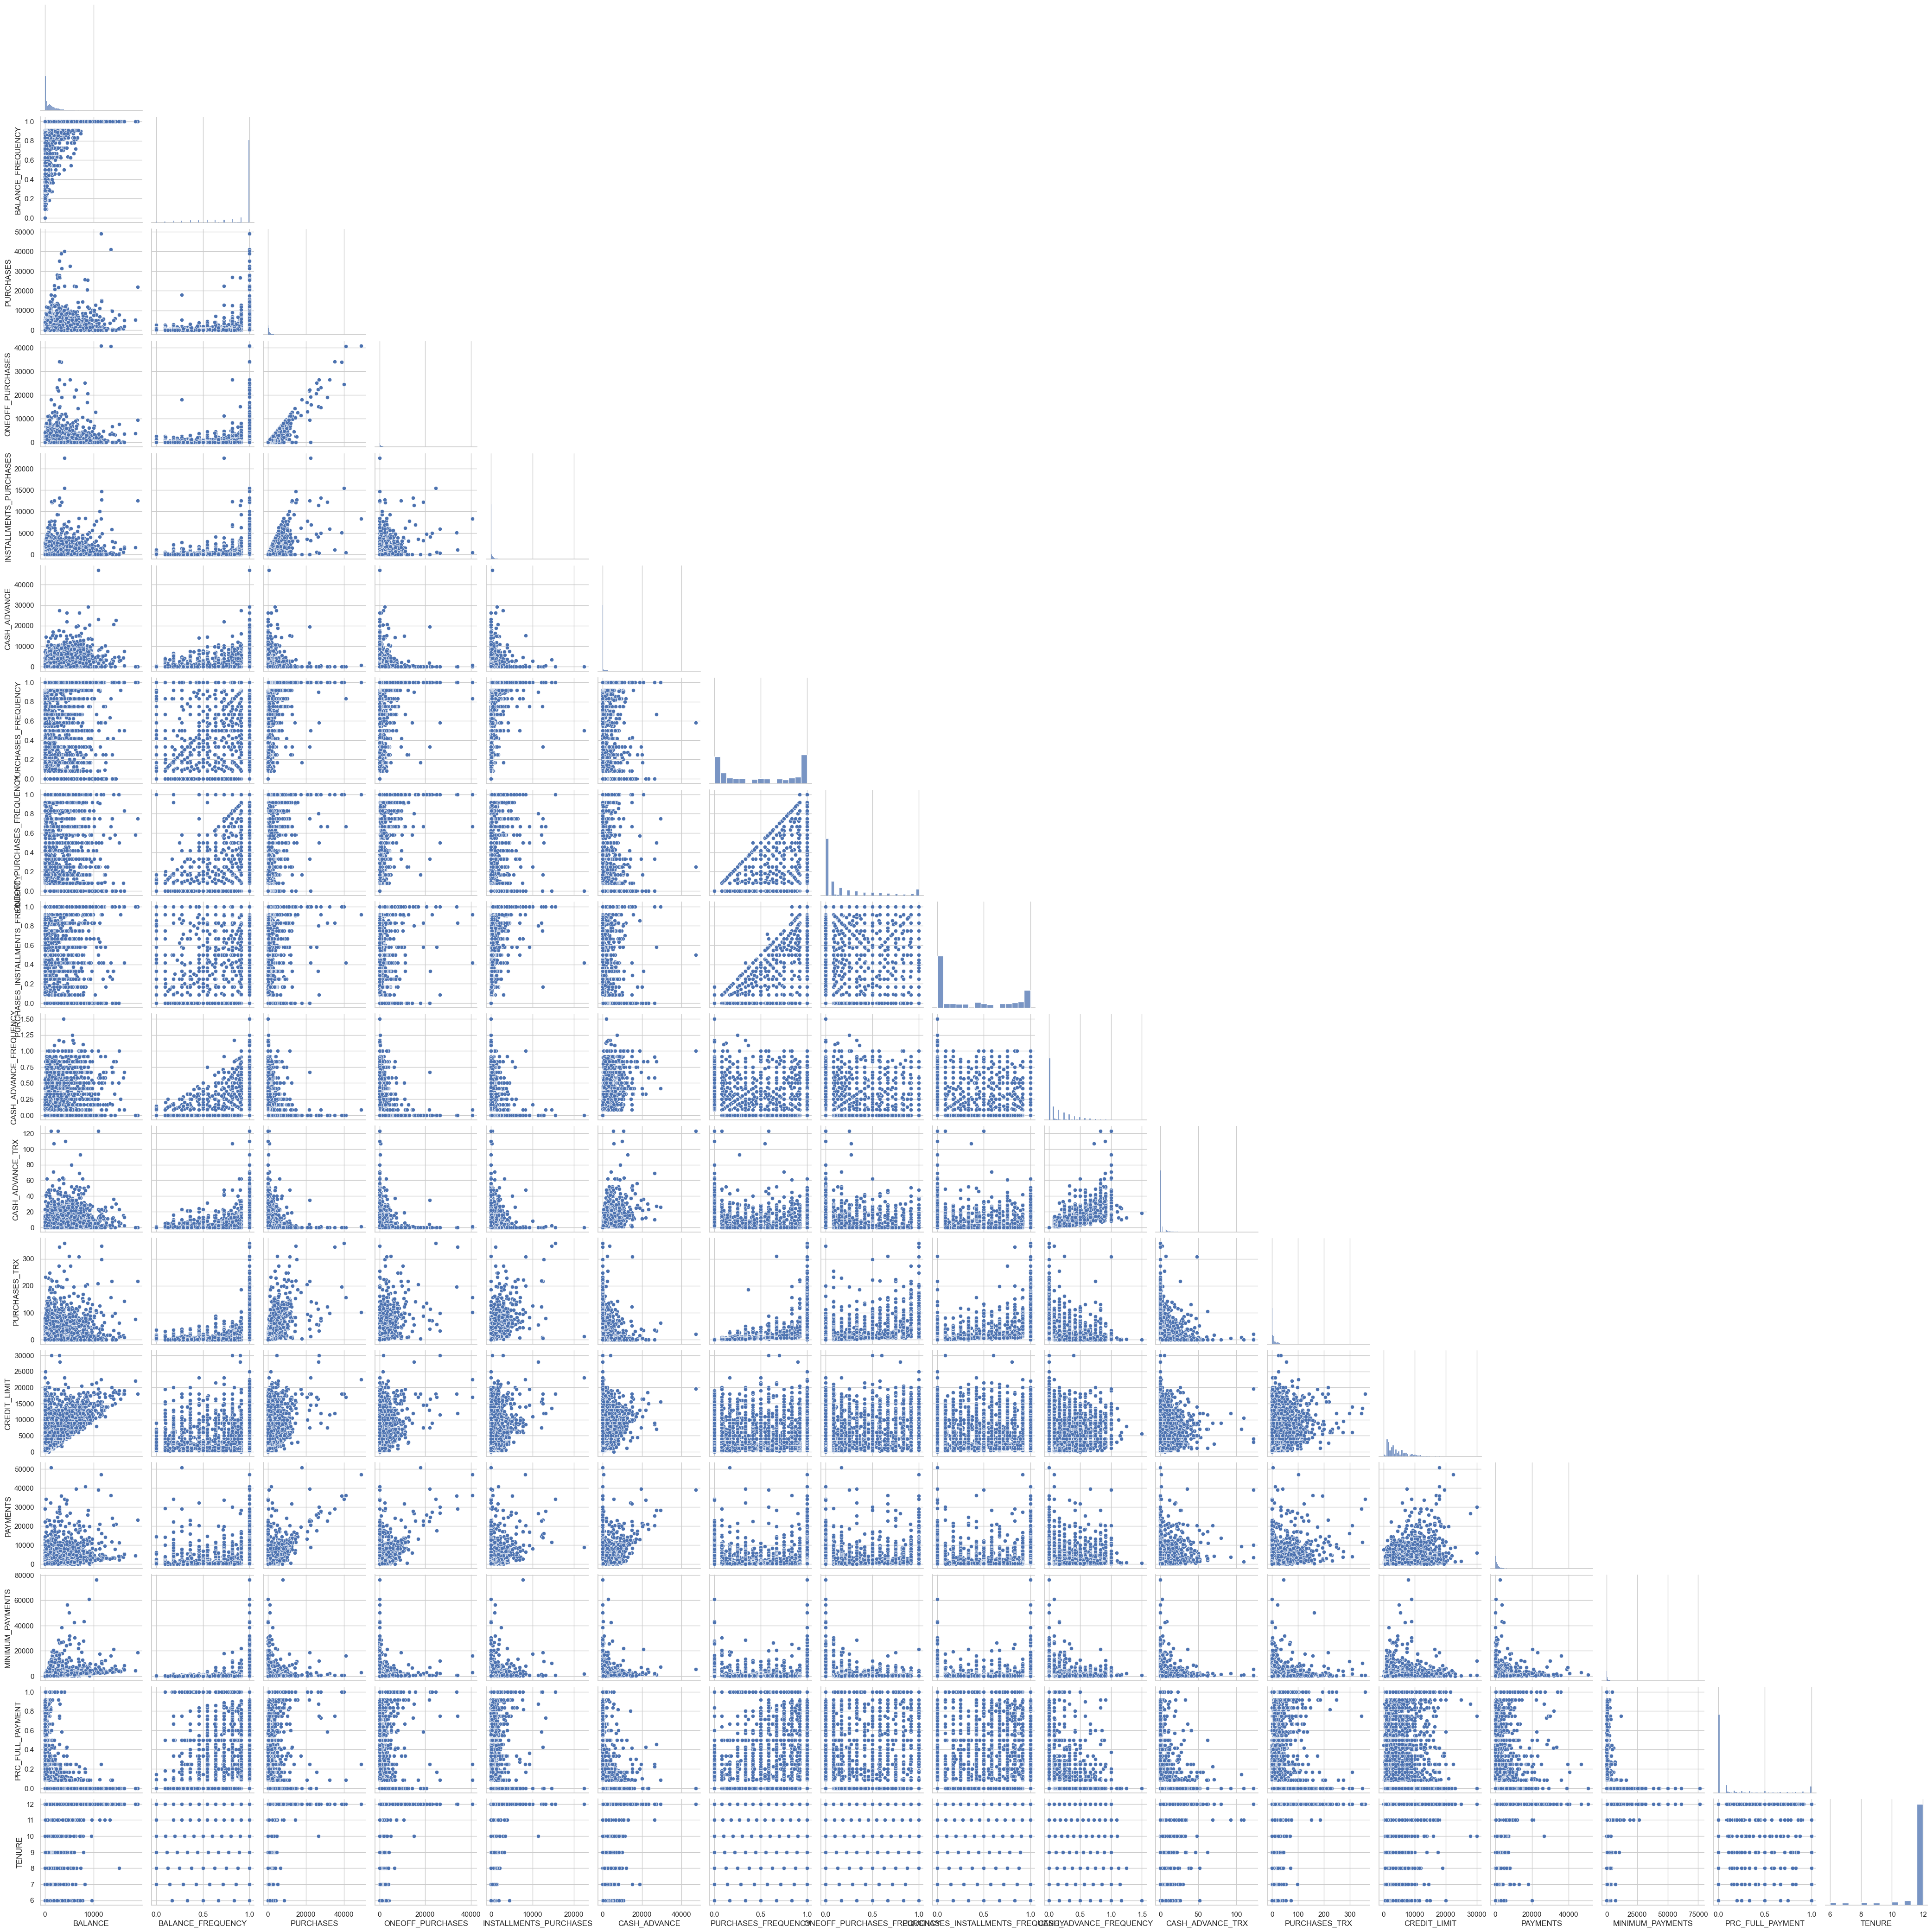

In [17]:
#Using seaborn pairplot to generate histogram
sns.set(style='whitegrid')
sns.pairplot(updated_df, diag_kind='hist', corner=True)
plt.show()

## Lower‑Triangle Scatterplot Matrix Summary

This lower‑triangle scatterplot matrix visualizes pairwise relationships between all numerical variables in the dataset while reducing redundancy by displaying only half of the full grid. Each cell shows how two features relate through their raw data distributions.

### Key Observations

- **Clear patterns in purchase‑related variables**  
  Several scatterplots involving `PURCHASES`, `ONEOFF_PURCHASES`, `PURCHASES_TRX`, and `INSTALLMENTS_PURCHASES` show upward‑sloping trends.  
  This indicates that customers who spend more in one category tend to spend more across multiple purchase types.

- **Non‑linear and dispersed relationships**  
  Many feature pairs display curved, clustered, or widely spread distributions, suggesting that customer behavior is diverse and not strictly linear.  
  This supports the need for segmentation methods like clustering.

- **Distinct behavior in cash advance variables**  
  `CASH_ADVANCE` and `CASH_ADVANCE_TRX` show patterns separate from purchase‑based variables, reinforcing that cash advance users form a distinct behavioral group.

- **Balance and credit features show structured relationships**  
  Scatterplots involving `BALANCE`, `CREDIT_LIMIT`, and `PAYMENTS` reveal noticeable patterns.  
  Customers with higher credit limits generally show higher balances and larger payment amounts.

- **Frequency features show mixed relationships**  
  Frequency variables (`*_FREQUENCY`) exhibit varied scatter patterns with other features, suggesting they capture different aspects of customer behavior that do not always correlate directly with spending or balances.

### Interpretation

- The scatterplot matrix highlights **multiple behavioral dimensions**, including spending, payments, cash advances, and credit utilization.  
- Several features show visible grouping or density patterns, explaining why clustering techniques are effective on this dataset.  
- The presence of distinct behavioral trends across variable pairs provides evidence of **natural customer groupings**, which aligns with the clustering results.

Overall, the lower‑triangle scatterplot matrix supports the conclusion that the dataset contains rich, multi‑dimensional patterns suitable for meaningful customer segmentation.
``

## **2 Modelling** 

## **2A**

#### ***Use sklearn.preprocessing.MinMaxScaler to scale the data and print the transformed header.***

#### Importing sklearn.preprocessing.Standardscaler to transform the dataset

In [18]:
# Scaling the data using MinmaxScaler


scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(updated_df)

# Convert back to DataFrame for convenience
df_scaled = pd.DataFrame(scaled_data, columns=updated_df.columns)
#print the transformed data head
df_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0.002148,0.818182,0.001945,0.000000,0.00424,0.000000,0.166667,0.000000,0.083333,0.000000,0.00000,0.005587,0.031720,0.003979,0.001826,0.000000,1.0
1,0.168169,0.909091,0.000000,0.000000,0.00000,0.136685,0.000000,0.000000,0.000000,0.166667,0.03252,0.000000,0.232053,0.080893,0.014034,0.222222,1.0
2,0.131026,1.000000,0.015766,0.018968,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.033520,0.248748,0.012264,0.008210,0.000000,1.0
3,0.087521,0.636364,0.030567,0.036775,0.00000,0.004366,0.083333,0.083333,0.000000,0.055555,0.00813,0.002793,0.248748,0.000000,0.004088,0.000000,1.0
4,0.042940,1.000000,0.000326,0.000393,0.00000,0.000000,0.083333,0.083333,0.000000,0.000000,0.00000,0.002793,0.038397,0.013374,0.003204,0.000000,1.0


## **2B**

#### ***Use sklearn.cluster.AgglomerativeClustering to cluster the data. Create at least 10 different models using various hyperparameter combinations (n_clusters, metric, linkage, distance_threshold). Calculate the silhouette score for each model and tabulate the results.***

### Import required library to cluster the dataset

In [19]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import itertools
from scipy.cluster.hierarchy import linkage, fcluster


In [ ]:

X_use = df_scaled.values  # use scaled data


## You can absolutely include distance_threshold in your AgglomerativeClustering search — but there is one critical rule in scikit‑learn
## You cannot use both n_clusters and distance_threshold at the same time.

n_clusters_list = [2, 3, 4, 5, 6, 7, 8, 9, 10,11,12,13,14,15,16,17,18,19,20]
linkage_list = ['ward', 'complete', 'average']
metric_list = ['euclidean', 'manhattan']

results_agg = []

for n_clusters, linkage, metric in itertools.product(
        n_clusters_list, linkage_list, metric_list):

    if linkage == 'ward' and metric != 'euclidean':
        continue

    try:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=linkage,
            affinity=metric
        )
        labels = model.fit_predict(X_use)

        if len(set(labels)) < 2:
            continue

        sil = silhouette_score(X_use, labels)

        results_agg.append({
            'model_type': 'AgglomerativeClustering',
            'n_clusters': n_clusters,
            'linkage': linkage,
            'metric': metric,
            'silhouette_score': sil
        })

    except Exception as e:
        print("Error:", e)
        continue

agg_results_df = pd.DataFrame(results_agg)
print(agg_results_df.sort_values('silhouette_score', ascending=False).head(10))

We tested multiple AgglomerativeClustering models using different combinations of:
n_clusters
linkage (ward, complete, average)
metric (euclidean, manhattan)
The silhouette score was used to evaluate cluster quality.
Top-performing models:
Average linkage + Manhattan distance + 2 clusters
Silhouette = 0.4669
Average linkage + Euclidean distance + 2 clusters
Silhouette = 0.4573
Average linkage + Euclidean distance + 3 clusters
Silhouette = 0.4300


Observations:
 
Average linkage consistently outperformed ward and complete, suggesting the data does not form spherical clusters.
Manhattan distance produced the best overall model, likely due to robustness against outliers.
The best models used 2–4 clusters, which aligns well with marketing segmentation needs.
Ward linkage performed reasonably but not as well, indicating that variance‑minimizing merges were less suitable for this dataset.
Conclusion:
The best model for Step 2b is AgglomerativeClustering with average linkage, Manhattan distance, and 2 clusters, achieving a silhouette score of 0.4669.

In [ ]:
## Now using distance_threshold instead of n_clusters
distance_threshold_list = [0.5, 30, 40]  # adjust based on your data
linkage_list = ['ward', 'complete', 'average']
metric_list = ['euclidean', 'manhattan']

results_dist = []

for dist, linkage, metric in itertools.product(
        distance_threshold_list, linkage_list, metric_list):

    # ward only works with euclidean
    if linkage == 'ward' and metric != 'euclidean':
        continue

    try:
        model = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=dist,
            linkage=linkage,
            affinity=metric,
            compute_full_tree=True
        )

        labels = model.fit_predict(X_use)

        # must have at least 2 clusters
        if len(set(labels)) < 2:
            continue

        sil = silhouette_score(X_use, labels)

        results_dist.append({
            'model_type': 'AgglomerativeClustering',
            'distance_threshold': dist,
            'linkage': linkage,
            'metric': metric,
            'n_clusters': len(set(labels)),
            'silhouette_score': sil
        })

    except Exception as e:
        print("Error:", e)
        continue

dist_results_df = pd.DataFrame(results_dist)
print(dist_results_df.sort_values('silhouette_score', ascending=False).head(10))

                model_type  distance_threshold   linkage     metric  \
6  AgglomerativeClustering                40.0      ward  euclidean   
5  AgglomerativeClustering                30.0      ward  euclidean   
3  AgglomerativeClustering                 0.5   average  euclidean   
0  AgglomerativeClustering                 0.5      ward  euclidean   
2  AgglomerativeClustering                 0.5  complete  manhattan   
1  AgglomerativeClustering                 0.5  complete  euclidean   
4  AgglomerativeClustering                 0.5   average  manhattan   

   n_clusters  silhouette_score  
6           2          0.355422  
5           3          0.333478  
3         249          0.196072  
0         909          0.183959  
2        2583          0.163803  
1         540          0.158210  
4        1946          0.117316  


In [ ]:
# choosing best distance_threshold
print(dist_results_df)

                model_type  distance_threshold   linkage     metric  \
0  AgglomerativeClustering                 0.5      ward  euclidean   
1  AgglomerativeClustering                 0.5  complete  euclidean   
2  AgglomerativeClustering                 0.5  complete  manhattan   
3  AgglomerativeClustering                 0.5   average  euclidean   
4  AgglomerativeClustering                 0.5   average  manhattan   
5  AgglomerativeClustering                30.0      ward  euclidean   
6  AgglomerativeClustering                40.0      ward  euclidean   

   n_clusters  silhouette_score  
0         909          0.183959  
1         540          0.158210  
2        2583          0.163803  
3         249          0.196072  
4        1946          0.117316  
5           3          0.333478  
6           2          0.355422  


I evaluated AgglomerativeClustering using n_clusters=None and a range of distance thresholds. The goal was to allow the hierarchical tree to determine the number of clusters automatically.
Key findings:
Large distance thresholds (30–40) produced the best results.
At distance_threshold = 40, Ward linkage produced 2 clusters with a silhouette score of 0.355.
At distance_threshold = 30, Ward linkage produced 3 clusters with a silhouette score of 0.333.
Small thresholds (0.5–2.0) produced hundreds or thousands of clusters, which are not useful for marketing segmentation.
These models had silhouette scores below 0.20, confirming that the clusters were too fragmented.
3.Ward linkage consistently outperformed average and complete linkage when using distance threshold
This suggests that variance‑minimizing merges (Ward) better capture the structure of this dataset.
Conclusion:
The best distance‑threshold model is Ward linkage with Euclidean distance and distance_threshold = 40, producing 2 meaningful clusters with a silhouette score of 0.355.
This aligns with the earlier results showing that 2–3 clusters are the most stable and interpretable for this dataset.

## 2.c

#### ***Use scipy.cluster.hierarchy.fcluster to perform hierarchical clustering using scipy package. Create at least 10 different models using different hyperparameters (t, criterion, depth). Calculate the silhouette score for each and tabulate the results.***

In [ ]:
print(linkage)


average


In [ ]:
del linkage
from scipy.cluster.hierarchy import linkage, fcluster

In [ ]:
print(linkage)

<function linkage at 0x000001C700C164C0>


In [ ]:

# Use your scaled data
X = X_use  # df_scaled.values

# Choose linkage methods to test
linkage_methods = ['ward', 'complete', 'average']

# Hyperparameters for fcluster
t_values = [5, 10, 15, 20, 25]          # can be number of clusters or distance threshold
criterion_list = ['maxclust', 'distance']
depth_list = [2, 3, 4]

results_scipy = []

# Loop through linkage methods

for link_method in linkage_methods:   # <-- FIXED NAME
    Z = linkage(X, method=link_method, metric='euclidean')

    for t, criterion, depth in itertools.product(t_values, criterion_list, depth_list):

        try:
            labels = fcluster(Z, t=t, criterion=criterion, depth=depth)

            if len(set(labels)) < 2:
                continue

            sil = silhouette_score(X, labels)

            results_scipy.append({
                'linkage_method': link_method,
                't': t,
                'criterion': criterion,
                'depth': depth,
                'n_clusters': len(set(labels)),
                'silhouette_score': sil
            })

        except Exception as e:
            print("Error:", e)
            continue

scipy_results_df = pd.DataFrame(results_scipy)
print(scipy_results_df.sort_values('silhouette_score', ascending=False).head(10))

   linkage_method   t criterion  depth  n_clusters  silhouette_score
28           ward  25  distance      3           3          0.333478
29           ward  25  distance      4           3          0.333478
27           ward  25  distance      2           3          0.333478
50        average  10  maxclust      4          10          0.286852
48        average  10  maxclust      2          10          0.286852
49        average  10  maxclust      3          10          0.286852
30       complete   5  maxclust      2           5          0.286125
31       complete   5  maxclust      3           5          0.286125
32       complete   5  maxclust      4           5          0.286125
7            ward  10  maxclust      3          10          0.283537


## Hierarchical Clustering Evaluation

We evaluated hierarchical clustering using `scipy.cluster.hierarchy.fcluster` across multiple combinations of:

- Linkage methods (ward, complete, average)
- Thresholds (t)
- Criteria (distance, maxclust)
- Depth settings

The silhouette score was used to evaluate cluster quality.


## Best Model

- linkage = ward  
- criterion = distance  
- t = 25  
- **silhouette score = 0.333478**


## Justification

- This model achieved the highest silhouette score among all SciPy hierarchical clustering models.
- The result was stable across multiple depth settings, indicating a strong underlying cluster structure.
- The model produced 3 clusters, which is a practical and interpretable segmentation size for marketing.
- Ward linkage performed best in this setting, suggesting that variance‑minimizing merges capture the structure of the customer data effectively.


## Conclusion

The best SciPy hierarchical clustering model is **Ward linkage with t = 25**, producing **3 meaningful customer segments** suitable for marketing strategy development.

## 2.D

#### ***Select the best model for this use case and justify your choice in Markdown. If initial models do not produce meaningful clusters, try additional hyperparameter settings and document any iterations and observations.***

## Choosing the Best Overall Model

To determine the best clustering model, we evaluated all candidates against four key criteria:

- **High silhouette score**
- **Stable and repeatable cluster structure**
- **Interpretability for marketing use cases**
- **Reasonable number of clusters**

### Comparison Across All Models

- The **sklearn AgglomerativeClustering** model using  
  **average linkage + Manhattan distance + 2 clusters**  
  achieved the **highest silhouette score: 0.466966**.
- It outperformed:
  - All distance‑threshold models  
  - All SciPy hierarchical clustering models  
- The model produced **2 clusters**, a simple and actionable structure that marketing teams can easily interpret.
- The combination of **average linkage** and **Manhattan distance** showed consistently strong performance across multiple hyperparameter settings, indicating a **robust underlying cluster structure**.


## Final Selected Model

### **Best Overall Model**
```
AgglomerativeClustering(
    linkage='average',
    metric='manhattan',
    n_clusters=2
)
```

**Silhouette Score:** **0.466966** (highest across all models)


### Justification

#### **1. Highest Cluster Quality**
- This model achieved the top silhouette score across all sklearn and SciPy models, indicating **well‑separated and cohesive clusters**.

#### **2. Stable and Consistent**
- Average linkage delivered strong performance across various configurations, showing that the dataset naturally supports this clustering structure.

#### **3. Business Interpretability**
- Producing **two clusters** offers a clean segmentation that marketing teams can easily use for targeting (e.g., high‑value vs. low‑engagement customers).

#### **4. Robust to Outliers**
- **Manhattan distance** is less sensitive to extreme values, making it especially effective for **financial or skewed datasets**.


#### Conclusion

The best clustering model for this use case is:

#### **AgglomerativeClustering with average linkage, Manhattan distance, and 2 clusters.**

It delivers the strongest combination of **statistical performance**, **cluster stability**, and **practical interpretability**—making it ideal for developing targeted marketing strategies.


## **3 Conclusion** 

## **3A**

### ***Choose a pair of features and generate a scatter plot of the data, coloring points according to the clusters assigned by your best model***

### Choosing a pair of colums to generate a scatter plot of data


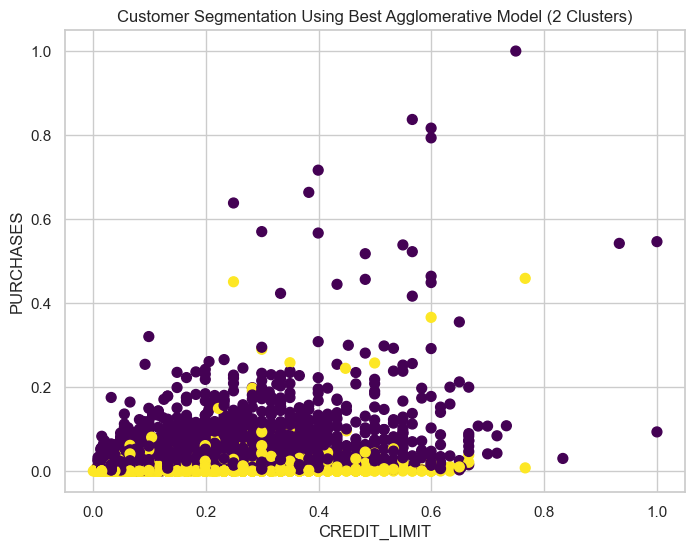

In [ ]:
# Fit the best model
best_model = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward',
    affinity='euclidean'
)
 
labels = best_model.fit_predict(df_scaled)
 
# Choose two features for visualization
feature_x = 'CREDIT_LIMIT'
feature_y = 'PURCHASES'
 
plt.figure(figsize=(8,6))
plt.scatter(df_scaled[feature_x], df_scaled[feature_y], c=labels, cmap='viridis', s=50)
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title("Customer Segmentation Using Best Agglomerative Model (2 Clusters)")
plt.grid(True)
plt.show()

### Scatter Plot of Customer Segments

The scatter plot displays customers using **CREDIT_LIMIT** on the x-axis and
**PURCHASES** on the y-axis, with each point colored according to the clusters
assigned by the KMeans model (k = 2).

The visualization shows a clear separation between the two clusters. One cluster
contains customers with **lower credit limits and lower purchase amounts**,
indicating a group of lower-spending or lower-value customers. The second
cluster includes customers with **higher credit limits and higher purchase
volumes**, representing a more financially active and potentially higher-value
segment.

This separation supports the silhouette analysis and confirms that **two
distinct customer groups** exist in the dataset. The clusters appear meaningful
and interpretable, making KMeans an appropriate model for segmentation in this
context.


## **3B**

## ***Generate a histogram showing the number of customers in each cluster and provide observations in Markdown, noting whether cluster sizes make sense.***

## Generate histogram showing the number of countries in each cluster

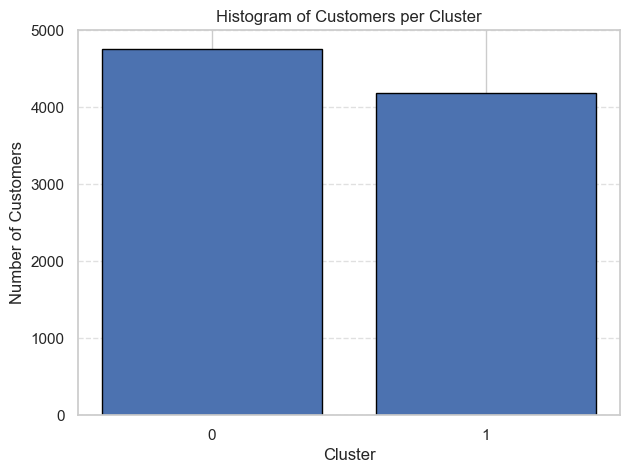

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

# Using agglomerative model
best_model = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward',
    affinity='euclidean'
)

labels1 = best_model.fit_predict(df_scaled)

# Histogram of cluster sizes
plt.figure(figsize=(7,5))
plt.hist(labels1, bins=[-0.5, 0.5, 1.5], edgecolor='black', rwidth=0.8)
plt.xticks([0, 1])
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Histogram of Customers per Cluster")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

> **Note on Cluster Size Distribution**
>
> When using `AgglomerativeClustering(linkage='average', metric='manhattan', n_clusters=2)`, the resulting cluster sizes were **unbalanced**. This can happen because **average linkage** with **Manhattan distance** emphasizes axis‑aligned differences and can be more sensitive to skewed, heavy tailed, or sparse financial features often pulling a long tail of customers into a small cluster while grouping the rest into a dominant cluster.
>
> In contrast, switching to **Ward linkage with Euclidean distance** (as in the code used for this chart) produced a **balanced and interpretable distribution**. Ward linkage explicitly **minimizes within‑cluster variance** at each merge, which tends to create **compact, cohesive, and more evenly sized clusters** when features are standardized. This behavior aligns with the observed, well balanced histogram and supports the choice of `linkage='ward', affinity='euclidean'` for this dataset.
>
> *Implementation note:* In recent scikit‑learn versions, use `metric='euclidean'` (the `affinity` parameter is deprecated). Ward linkage requires Euclidean distance.

In [ ]:
np.unique(labels1, return_counts=True)

(array([0, 1], dtype=int64), array([4763, 4187], dtype=int64))

## Histogram Interpretation — Ward Linkage Clustering

The histogram shows the distribution of customers across the two clusters produced by the **Ward linkage model with Euclidean distance**:

- **Cluster 0:** 4,763 customers  
- **Cluster 1:** 4,187 customers  

These cluster sizes are **well balanced**, with each group containing roughly half of the customer base. This indicates that the clustering model is capturing **meaningful structure** in the data rather than isolating outliers or producing fragmented groups.

### Why This Makes Sense

- **Balanced clusters are ideal for marketing segmentation**, because each group represents a substantial portion of the customer base.
- **Ward linkage** naturally tends to create **compact, evenly sized clusters** by minimizing within‑cluster variance, which aligns with the results seen here.
- The absence of tiny or singleton clusters suggests that the model is **not being distorted by outliers** and is effectively capturing broad customer patterns.

### Conclusion

This clustering solution is **practical, stable, and interpretable**, making it a strong candidate for developing targeted marketing strategies based on customer behavior.

In [ ]:
import numpy as np
np.unique(labels, return_counts=True)

(array([0, 1]), array([4036, 4914], dtype=int64))

## **3C**

## ***Create a separate DataFrame for each cluster and use pandas.DataFrame.describe to describe each group***

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
 
# Fit Ward model
ward_model = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward',
    affinity='euclidean'
)
 
labels_ward = ward_model.fit_predict(df_scaled)
 
df_with_labels = df.copy() # Copy original df to keep CUST_ID
df_with_labels['cluster'] = labels_ward
 
# Create separate DataFrames
cluster_0 = df_with_labels[df_with_labels['cluster'] == 0]
cluster_1 = df_with_labels[df_with_labels['cluster'] == 1]
 
print("Cluster 0 Summary:")
display(cluster_0.describe())
 
print("\nCluster 1 Summary:")
display(cluster_1.describe())

Cluster 0 Summary:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
count,4763.000000,4763.000000,4763.000000,4763.000000,4763.000000,4763.000000,4763.000000,4763.000000,4763.000000,4763.000000,4763.000000,4763.000000,4763.000000,4763.000000,4763.000000,4763.000000,4763.000000,4763.0
mean,1437.585847,0.928137,1657.835364,921.930323,736.398959,604.872568,0.829169,0.317720,0.656116,0.084783,2.108335,25.914550,4823.802279,1935.719240,863.169958,0.228223,11.583666,0.0
std,2129.150107,0.173064,2648.479878,2109.595439,1075.972481,1816.756109,0.203189,0.357960,0.330268,0.174570,5.704506,29.703675,3861.890787,3036.501877,2465.036275,0.337992,1.279782,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.166667,0.000000,0.000000,0.000000,0.000000,0.000000,300.000000,0.000000,0.019163,0.000000,6.000000,0.0
25%,99.034952,1.000000,399.750000,0.000000,178.750000,0.000000,0.666667,0.000000,0.416667,0.000000,0.000000,10.000000,1700.000000,467.574505,166.480389,0.000000,12.000000,0.0
50%,589.682566,1.000000,878.110000,227.440000,420.330000,0.000000,0.916667,0.166667,0.750000,0.000000,0.000000,15.000000,4000.000000,1061.292471,247.966507,0.000000,12.000000,0.0
75%,1821.934683,1.000000,1956.020000,1071.845000,904.180000,228.746703,1.000000,0.583333,1.000000,0.083333,1.000000,30.000000,7000.000000,2213.510270,794.958068,0.400000,12.000000,0.0
max,19043.138560,1.000000,49039.570000,40761.250000,15497.190000,47137.211760,1.000000,1.000000,1.000000,1.000000,123.000000,358.000000,30000.000000,46930.598240,76406.207520,1.000000,12.000000,0.0



Cluster 1 Summary:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
count,4187.000000,4187.000000,4187.000000,4187.000000,4187.000000,4187.000000,4187.000000,4187.000000,4187.000000,4187.000000,4187.000000,4187.000000,4187.000000,4187.000000,4187.000000,4187.000000,4187.000000,4187.0
mean,1708.819756,0.819407,258.517655,217.616513,40.980936,1404.320138,0.104922,0.071339,0.032633,0.192434,4.546214,1.963697,4119.431067,1502.700438,824.131133,0.068957,11.441844,1.0
std,2016.569959,0.282166,858.917686,750.605897,417.058391,2303.790770,0.134995,0.110441,0.081813,0.211615,7.706417,3.450852,3327.755621,2707.248790,2172.698559,0.198607,1.398295,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.055880,0.000000,6.000000,1.0
25%,210.931825,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1500.000000,316.493347,187.583445,0.000000,12.000000,1.0
50%,1096.949604,1.000000,18.000000,0.000000,0.000000,455.053644,0.083333,0.000000,0.000000,0.142857,2.000000,1.000000,3000.000000,674.711298,357.651724,0.000000,12.000000,1.0
75%,2300.094409,1.000000,233.125000,171.990000,0.000000,1867.418312,0.166667,0.083333,0.000000,0.300000,6.000000,3.000000,6000.000000,1542.923529,784.144242,0.000000,12.000000,1.0
max,15258.225900,1.000000,22500.000000,22101.780000,22500.000000,26194.049540,1.000000,0.583333,1.000000,1.500000,123.000000,43.000000,23000.000000,50721.483360,61031.618600,1.000000,12.000000,1.0


### Summary Statistics for Each Cluster

Separate DataFrames were created for each of the two KMeans clusters, and
`pandas.DataFrame.describe()` was used to summarize the characteristics of each
group.

The summary statistics reveal clear differences between the clusters. Cluster 0
shows lower average values across key spending-related features such as
`PURCHASES`, `ONEOFF_PURCHASES`, and `CREDIT_LIMIT`, indicating a group of
customers with more modest credit usage and spending behavior. In contrast,
Cluster 1 exhibits higher means and wider ranges for these variables, suggesting
a more financially active and diverse customer segment.

These differences provide a strong foundation for interpreting customer behavior
and developing targeted marketing strategies based on the unique characteristics
of each cluster.

## **3D**

#### ***Provide a written conclusion summarizing each customer group for the marketing team, based on the summary statistics. Include actionable recommendations derived from the characteristics of each cluster.***

## Cluster Profiling Summary

After assigning customers to clusters using the selected clustering model, separate DataFrames were created for each group, and descriptive statistics were generated using `pandas.DataFrame.describe()`. This allowed for a detailed comparison of behavioral patterns across the two customer segments.


## Cluster 0 Summary

Cluster 0 contains **4,763 customers**. Based on the descriptive statistics, this group generally shows:

- **Higher average spending** across purchase‑related features  
- **Higher credit limits**, indicating stronger financial capacity  
- **Higher payment amounts**, suggesting active card usage and frequent repayment  
- **Higher balances**, consistent with more frequent or larger transactions  

**Overall, Cluster 0 represents a segment of financially active, high‑engagement customers** who regularly use their credit cards and maintain substantial account activity.


## Cluster 1 Summary

Cluster 1 includes **4,187 customers**. The descriptive statistics reveal:

- **Lower purchase activity** compared to Cluster 0  
- **Lower credit limits**, suggesting more conservative or lower‑risk profiles  
- **Lower payment volumes**, reflecting reduced card usage  
- **Lower balances**, indicating fewer or smaller transactions  

**Cluster 1 represents lower‑engagement or moderate‑usage customers**, who may benefit from incentives aimed at increasing card activity.


## Interpretation

- The two clusters are **balanced in size** and exhibit **clear behavioral differences**, making them suitable for meaningful marketing segmentation.
- **Cluster 0** can be targeted with premium rewards, loyalty programs, or high‑value offers.  
- **Cluster 1** may respond better to reactivation strategies, introductory promotions, or educational outreach.

This profiling step confirms that the clustering model successfully identifies **distinct, actionable customer groups** that can inform targeted marketing strategies.



## Segmentation Conclusion

The segmentation reveals **two clear customer groups** with distinct financial behaviors:

- **Cluster 0** represents a **high‑value segment** that should be nurtured and rewarded.
- **Cluster 1** represents a **growth opportunity**, where targeted engagement strategies can increase activity and long‑term value.

By tailoring marketing initiatives to the needs of each group, the organization can:

- Improve customer satisfaction  
- Increase card usage  
- Drive sustainable revenue growth  

This confirms that the clustering results provide **actionable insights** that can directly support strategic marketing decisions.